<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/dars41part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# customerID ustunini tashlab yuboramiz
df.drop(columns=['customerID'], inplace=True)

# TotalCharges ustunidagi bo'shliqlarni yo'qotib, numeric (float64) ga o'tkazamiz
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Bo'sh qolib ketgan (NaN bo'lib qolgan) 11 ta qiymatni median yoki 0 bilan to'ldiramiz
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_4736/4197472710.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [8]:
# Target ustunini 1 va 0 ga o'tkazish
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Barcha categorical (object) ustunlarni One-Hot Encoding qilish
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Train-Test ga ajratish (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Masshtablash (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shakli:", X_train_scaled.shape)
print("X_test shakli:", X_test_scaled.shape)

X_train shakli: (5634, 30)
X_test shakli: (1409, 30)


In [10]:
import time
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Modellarni e'lon qilamiz
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []

# 2. Har bir modelni o'qitib, vaqti va metrikalarini hisoblaymiz
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    exec_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # ROC-AUC uchun ehtimollik

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Time (s)": exec_time
    })

# 3. Natijalarni DataFrame shaklida chiqarish
df_results = pd.DataFrame(results)
print("--- MODEL COMPARISON RESULTS ---")
print(df_results.to_string(index=False))

--- MODEL COMPARISON RESULTS ---
            Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)
Gradient Boosting  0.798439   0.653061 0.513369  0.574850 0.842094  1.331573
    Random Forest  0.785664   0.621622 0.491979  0.549254 0.824645  0.775777
          XGBoost  0.774308   0.587500 0.502674  0.541787 0.818571  0.210482


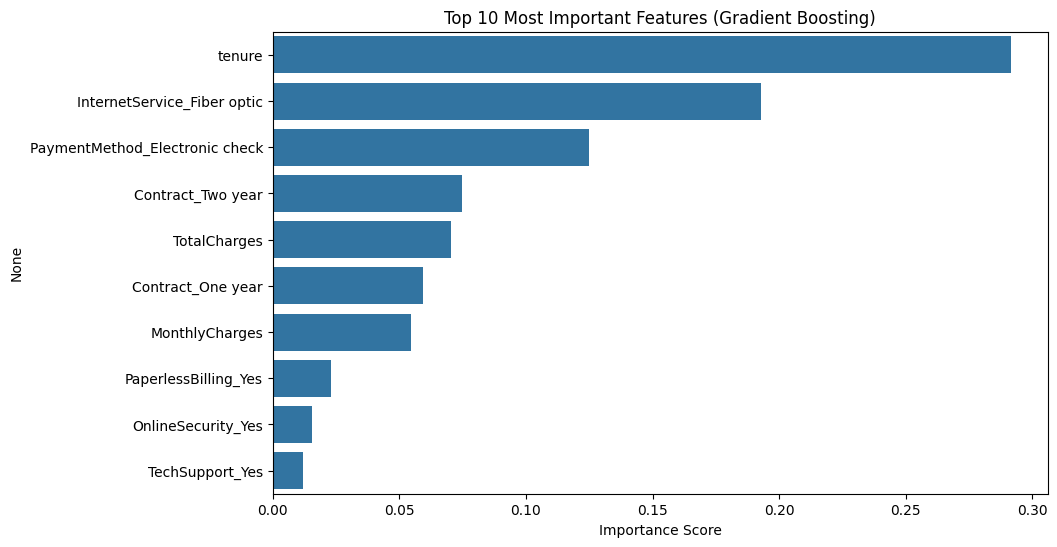

In [11]:
# Masalan, Gradient Boosting uchun Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(
    models["Gradient Boosting"].feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Top 10 Most Important Features (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.show()

Telco Customer Churn Loyihasi Boyicha Yakuniy Xulosa:


Model Tanlovi: Telco Churn datasetida 3 ta model o'zaro solishtirilganda Gradient Boosting Classifier eng yuqori natijani ko'rsatdi (Accuracy: 79.8%, ROC-AUC: 84.2%).  


Tezlik: XGBoost eng tez o'qitildi (0.21 soniya), ammo sifat bo'yicha Gradient Boosting'dan biroz ortda qoldi.  


Biznes Analitika (Muhim Xususiyatlar): Feature Importance tahliliga ko'ra, mijozlarning saqlanib qolishi yoki ketib qolishiga eng birinchi navbatda Ularning kompaniyadagi staji (tenure), ishlatadigan internet turi (Fiber optic) va Shartnoma turi (Contract) ta'sir qiladi.

In [13]:
from sklearn.model_selection import GridSearchCV

# 1. Har bir model uchun alohida parametrlar lug'ati
param_grids = {
    "Gradient Boosting": {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [10, 15],
        'min_samples_split': [2, 5]
    },
    "XGBoost": {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    }
}

# Modellarning boshlang'ich ob'ektlari
base_models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

best_tuned_results = []

# 2. Har bir model bo'yicha alohida GridSearchCV o'tkazamiz
for name, model in base_models.items():
    print(f"{name} uchun eng yaxshi giperparametrlarni qidirish...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train)

    # Eng yaxshi o'qitilgan modelni olamiz
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    best_tuned_results.append({
        "Model": name,
        "Best Params": str(grid.best_params_),
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "F1-Score": f1_score(y_test, y_pred)
    })

# 3. Natijalarni jadvalga o'tkazamiz
df_tuned = pd.DataFrame(best_tuned_results)
df_tuned

Gradient Boosting uchun eng yaxshi giperparametrlarni qidirish...
Random Forest uchun eng yaxshi giperparametrlarni qidirish...
XGBoost uchun eng yaxshi giperparametrlarni qidirish...


,Model,Best Params,Accuracy,ROC-AUC,F1-Score
0,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.797729,0.846213,0.566210
1,Random Forest,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.800568,0.841716,0.579970
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.799148,0.845430,0.570561
